In [5]:
DATA_DIR = 'data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Master
products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date']) #
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date']) #
geography = pd.read_csv(DATA_DIR + 'geography.csv')
# Transaction
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date']) #
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date']) #
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date']) #
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date']) #
# Analytical
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date']) #
# Operational
inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date']) #
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')

# Data cleaning & Preprocessing

In [12]:
def quick_check(df, df_name):
    print(f"\n{'='*10} CHECKING TABLE: {df_name} {'='*10}")
    # Overall
    df.info()
    print(df.describe())

    # 1. Duplicates
    print(f"Duplicates: {df.duplicated().sum()} rows")

    # 2. Null values
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("Nulls found:\n", null_counts[null_counts > 0])
    else:
        print("No null values.")

    # 3. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

In [13]:
quick_check(products, 'products')
quick_check(customers, 'customers')
quick_check(promotions, 'promotions')
quick_check(geography, 'geography')
quick_check(orders, 'orders')
quick_check(order_items, 'order_items')
quick_check(payments, 'payments')
quick_check(shipments, 'shipments')
quick_check(returns, 'returns')
quick_check(reviews, 'reviews')
quick_check(sales, 'sales')
quick_check(inventory, 'inventory')
quick_check(web_traffic, 'web_traffic')


========== CHECKING TABLE: products ==========
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   7720.513784   586

- The data seems clean with valid values, only `promotion` and `order_items` have null values.
- Next we'll deal with this and also check for some specific constraints given in the task.

In [14]:
invalid_products = products[products['cogs'] >= products['price']]
len(invalid_products)

0

In [15]:
display(promotions.head())
print('\n', promotions['applicable_category'].unique())

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000



 <StringArray>
[nan, 'Streetwear', 'Outdoor']
Length: 3, dtype: str


In [16]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('Any')

In [17]:
promotions['promo_type'].unique()

<StringArray>
['percentage', 'fixed']
Length: 2, dtype: str

In [18]:
display(order_items.head())
print('\n', order_items['promo_id'].unique())
print('\n', order_items['promo_id_2'].unique())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN



 <StringArray>
[         nan, 'PROMO-0006', 'PROMO-0001', 'PROMO-0002', 'PROMO-0005',
 'PROMO-0003', 'PROMO-0004', 'PROMO-0007', 'PROMO-0008', 'PROMO-0009',
 'PROMO-0010', 'PROMO-0016', 'PROMO-0011', 'PROMO-0012', 'PROMO-0015',
 'PROMO-0013', 'PROMO-0014', 'PROMO-0017', 'PROMO-0018', 'PROMO-0019',
 'PROMO-0020', 'PROMO-0026', 'PROMO-0021', 'PROMO-0022', 'PROMO-0025',
 'PROMO-0023', 'PROMO-0024', 'PROMO-0027', 'PROMO-0028', 'PROMO-0029',
 'PROMO-0030', 'PROMO-0036', 'PROMO-0031', 'PROMO-0032', 'PROMO-0035',
 'PROMO-0033', 'PROMO-0034', 'PROMO-0037', 'PROMO-0038', 'PROMO-0039',
 'PROMO-0040', 'PROMO-0046', 'PROMO-0041', 'PROMO-0042', 'PROMO-0045',
 'PROMO-0043', 'PROMO-0044', 'PROMO-0047', 'PROMO-0048', 'PROMO-0049',
 'PROMO-0050']
Length: 51, dtype: str

 <StringArray>
[nan, 'PROMO-0015', 'PROMO-0025']
Length: 3, dtype: str


In [19]:
order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('No_Promo')

# EDA & Data Storytelling

## Sales and related criterias

In [20]:
sales = sales.set_index('Date')
sales.head()

,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79


In [21]:
monthly_revenue = sales['Revenue'].resample('ME').sum()
monthly_revenue.head()

Date
2012-07-31    1.304068e+08
2012-08-31    1.590892e+08
2012-09-30    1.293071e+08
2012-10-31    1.101857e+08
2012-11-30    9.818630e+07
Freq: ME, Name: Revenue, dtype: float64

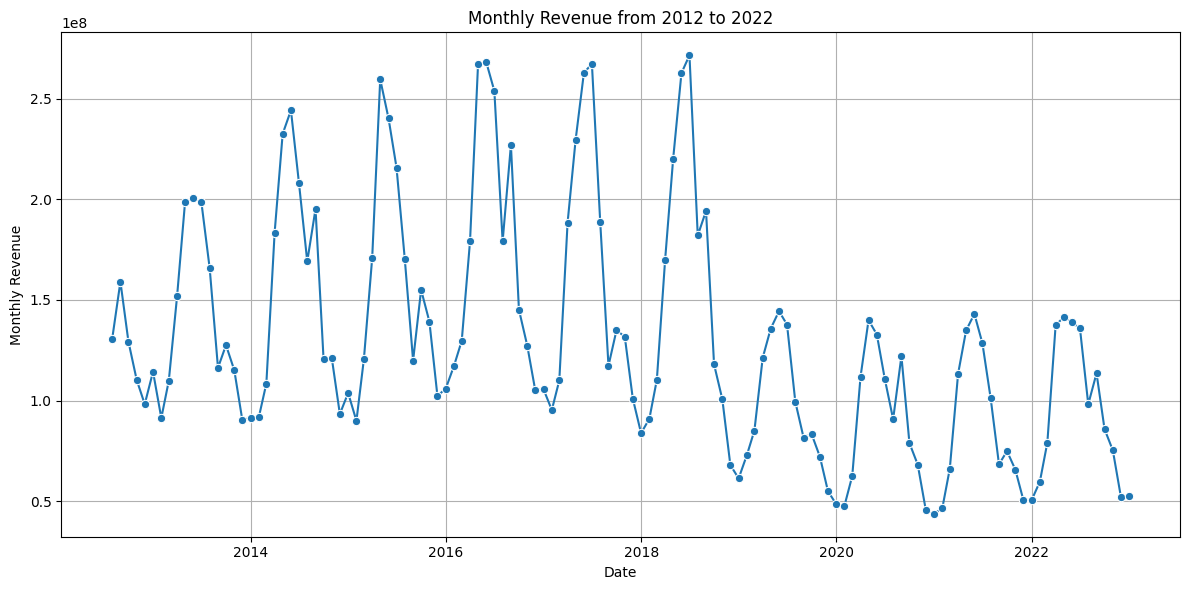

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')
plt.title('Monthly Revenue from 2012 to 2022')
plt.xlabel('Date')
plt.ylabel('Monthly Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Đánh giá xu hướng

Biểu đồ doanh thu hàng tháng từ năm 2012 đến 2022 cho thấy một số xu hướng đáng chú ý:

*   **Xu hướng tăng trưởng tổng thể**: Nhìn chung, doanh thu có xu hướng tăng dần theo thời gian, đặc biệt là trong những năm đầu.
*   **Tính thời vụ rõ rệt**: Có vẻ như có các đỉnh doanh thu lặp lại hàng năm, thường vào cuối năm (ví dụ, quý 4), cho thấy tính thời vụ trong hoạt động kinh doanh.
*   **Biến động hàng tháng**: Doanh thu có sự biến động đáng kể giữa các tháng, nhưng các mức cao nhất và thấp nhất có vẻ duy trì một khoảng nhất định.
*   **Sự suy giảm gần đây**: Có thể quan sát thấy một sự suy giảm hoặc chững lại trong tăng trưởng doanh thu ở những năm gần đây của giai đoạn (ví dụ, 2020-2022), điều này có thể liên quan đến các yếu tố kinh tế vĩ mô hoặc cạnh tranh thị trường.

Further analyze the seasonal patterns to identify specific months or quarters with consistently high or low revenue, which could inform inventory management, marketing campaigns, and staffing decisions.

### Calculate Average Monthly Revenue


In [23]:
avg_monthly_revenue = monthly_revenue.groupby(monthly_revenue.index.month).mean()
print(avg_monthly_revenue)

Date
1     8.032579e+07
2     9.815858e+07
3     1.527737e+08
4     1.959886e+08
5     2.038379e+08
6     1.928133e+08
7     1.431826e+08
8     1.376770e+08
9     1.139348e+08
10    1.023845e+08
11    7.833885e+07
12    7.825484e+07
Name: Revenue, dtype: float64


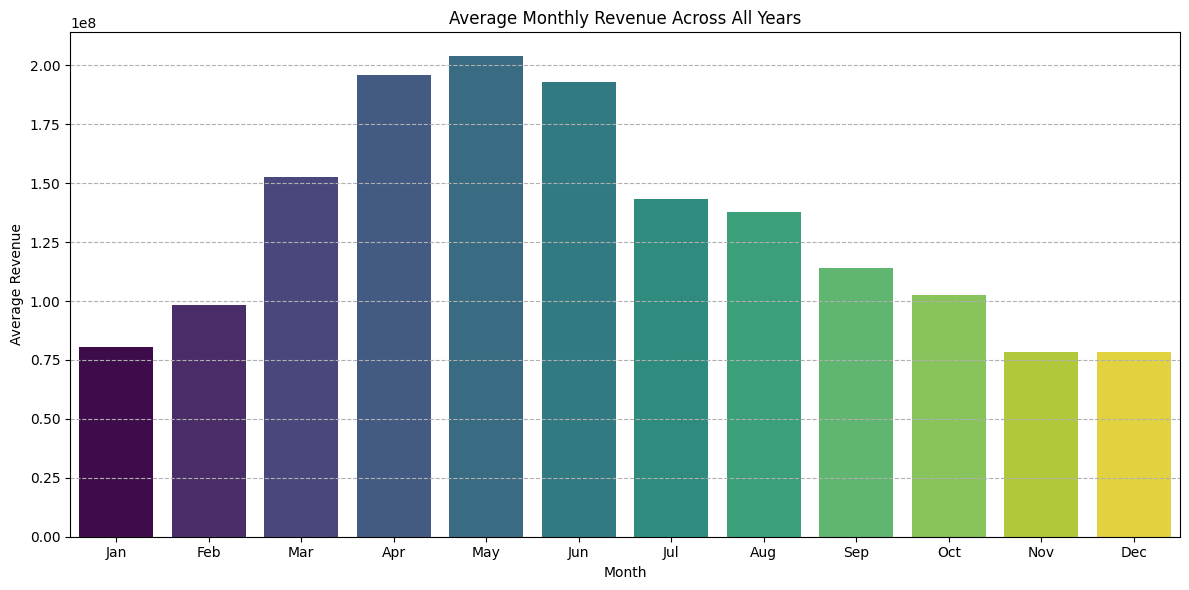

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_monthly_revenue.index, y=avg_monthly_revenue.values, palette='viridis', hue=avg_monthly_revenue.index, legend=False)
plt.title('Average Monthly Revenue Across All Years')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Calculate Average Quarterly Revenue

In [25]:
avg_quarterly_revenue = monthly_revenue.groupby(monthly_revenue.index.quarter).mean()
print(avg_quarterly_revenue)

Date
1    1.104194e+08
2    1.975466e+08
3    1.315981e+08
4    8.632606e+07
Name: Revenue, dtype: float64


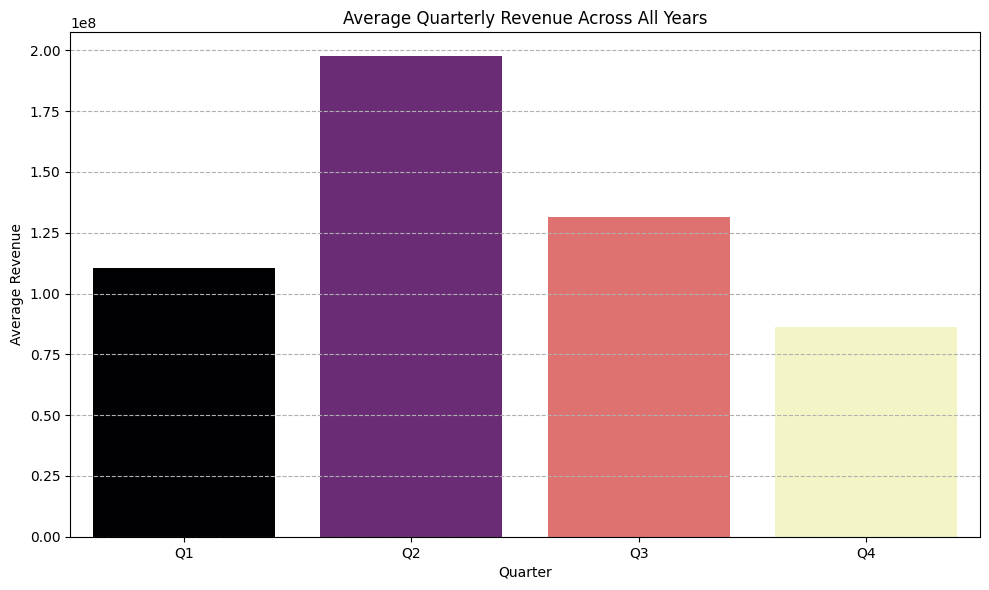

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_quarterly_revenue.index, y=avg_quarterly_revenue.values, palette='magma', hue=avg_quarterly_revenue.index, legend=False)
plt.title('Average Quarterly Revenue Across All Years')
plt.xlabel('Quarter')
plt.ylabel('Average Revenue')
plt.xticks(ticks=range(0, 4), labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

####  Data Analysis Key Findings

*   **Average Monthly Revenue**: The average monthly revenue exhibits a clear seasonal pattern, with the highest revenues observed during Q2 (April, May, June) and a strong performance continuing into Q3 (July, August, September). December and January tend to have the lowest average revenues.
*   **Average Quarterly Revenue**: Q2 is consistently the strongest period for revenue, followed by Q3. Revenue generally declines in Q4 and remains lower in Q1.

#### Insights or Next Steps

*   **Strategic Resource Allocation**: Businesses should allocate higher marketing budgets and resources to Q2 and Q3 to capitalize on peak demand, while optimizing inventory and staffing for lower demand periods in Q4 and Q1.
*   **Targeted Business Operations**: Consider timing major product launches for Q2 to maximize initial sales and implement targeted promotions during slower months (Q4, Q1) to stimulate demand or clear old stock.


Next: Investigate the factors contributing to the observed revenue slowdown in 2019-2022, which could include macroeconomic changes, increased competition, or shifts in customer behavior.

## Promotions and related criterias

# Feature engineering

#### (Tham khảo)
Đây là bước quyết định mô hình dự báo chính xác hay không. Mục tiêu là biến 15 bảng thành 1 bảng df_train duy nhất, mỗi dòng là 1 ngày (Daily).

##### Bước 3.1: Tạo Time-Series Backbone (Khung xương)
Tạo một DataFrame với cột Date chạy dài từ 2012-07-04 đến 2024-07-01.Left Join bảng sales.csv vào đây. Các ngày không có doanh thu sẽ bị null $\rightarrow$ Điền 0.

##### Bước 3.2: Tạo Temporal Features (Đặc trưng Lịch - An toàn không leak)
* Từ cột Date, trích xuất các cột:day_of_week (0-6), day_of_month, month, quarter, year.is_weekend (1 nếu thứ 7, CN, ngược lại 0).
* Cực kỳ quan trọng: Tạo cột is_holiday (Dùng thư viện holidays của Python để cắm các ngày lễ của Việt Nam như Tết Nguyên Đán, 30/4, 2/9) và các ngày Mega Sale E-commerce (9/9, 11/11, 12/12).days_until_next_holiday: Khoảng cách tính bằng ngày đến ngày lễ tiếp theo (bắt được tâm lý chờ sale của khách hàng).

##### Bước 3.3: Aggregate các bảng vệ tinh theo ngày (Exogenous Features)
Bạn cần gom các bảng giao dịch thành dạng Daily (theo ngày đặt hàng) và PHẢI LAG (LÙI NGÀY) để không rò rỉ tương lai.
* Khuyến mãi (promotions): Lấy lịch khuyến mãi. Tạo cột: Hôm nay có bao nhiêu Promo đang chạy? Có Promo nào cho phép stackable không? Độ sâu giảm giá lớn nhất hôm nay là bao nhiêu? (Cái này không cần lag vì là lịch biết trước).
* Traffic (web_traffic): Sum số lượt truy cập (visits) theo ngày. Lùi 1 ngày $\rightarrow$ traffic_lag_1. (Tức là dùng traffic hôm qua để dự báo doanh thu hôm nay).
* Tồn kho (inventory): Vì bảng này chốt theo cuối tháng, bạn phải dùng hàm ffill() (Forward fill) để kéo giá trị tồn kho của ngày 31 tháng trước cho tất cả các ngày trong tháng hiện tại.Chất lượng dịch vụ (reviews, returns): Tính điểm rating trung bình 7 ngày qua (rating_rolling_7), hoặc tổng số lượng hàng bị trả lại 7 ngày qua.

##### Bước 3.4: Tạo Lag & Rolling Features cho Target (Revenue)
Đây là tính năng "ăn tiền" nhất của thuật toán (như XGBoost, LightGBM):Lags: revenue_lag_1, revenue_lag_2, revenue_lag_7, revenue_lag_30, revenue_lag_364 (so với cùng kỳ năm ngoái).Rolling Stats: Doanh thu trung bình (mean), lớn nhất (max), độ lệch chuẩn (std) của 7 ngày và 30 ngày trước đó. (Lưu ý: Phải .shift(1) cột Revenue trước khi tính rolling).